<a href="https://colab.research.google.com/github/Oshan001/Image-Processing/blob/main/Lab2%20from%20Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) Progam to Detect edge of an image

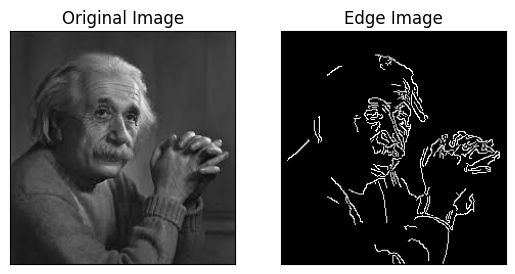

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('/content/Einstein.jpg',0)
edges = cv2.Canny(img,100,200)
plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

# 2) Write a program to scale an image

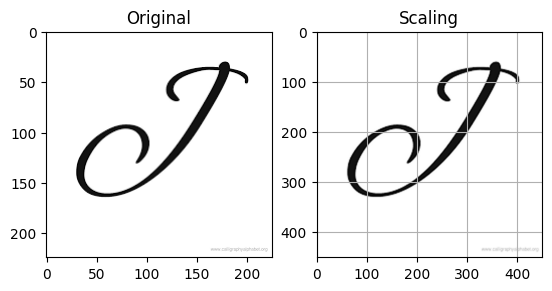

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('/content/j.png')
height, width = img.shape[:2]
res = cv2.resize(img,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.grid(True)
plt.subplot(122),plt.imshow(res),plt.title('Scaling')
plt.grid(True)
plt.show()


# 3) Write a program to thresholding on an image

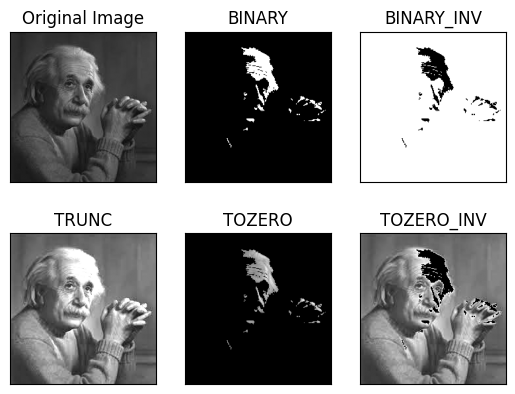

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread("/content/Einstein.jpg",0)
ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)
titles = ["Original Image","BINARY","BINARY_INV","TRUNC","TOZERO","TOZERO_INV"]
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
for i in range(6):
  plt.subplot(2,3,i+1),plt.imshow(images[i],"gray")
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

# 4) Log Transformation

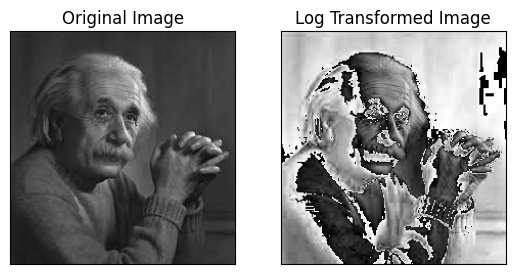

In [29]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('/content/Einstein.jpg', 0)
c = 255 / np.log(1 + np.max(img))
log_transformed = c * (np.log(img + 1))
log_transformed = np.array(log_transformed, dtype=np.uint8)
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(log_transformed, cmap='gray')
plt.title('Log Transformed Image')
plt.xticks([]), plt.yticks([])
plt.show()

# 5) Gama Transformation

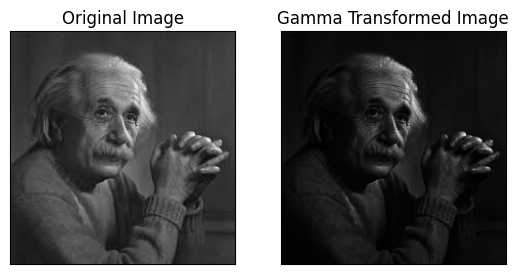

In [16]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img = cv2.imread('/content/Einstein.jpg', 0)
gamma = 2.0    # The value of Gama increases the image darkness increases
gamma_corrected = np.array(255 * (img / 255) ** gamma, dtype='uint8')
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(gamma_corrected, cmap='gray')
plt.title('Gamma Transformed Image')
plt.xticks([]), plt.yticks([])
plt.show()

# 6) Contrast Stretching

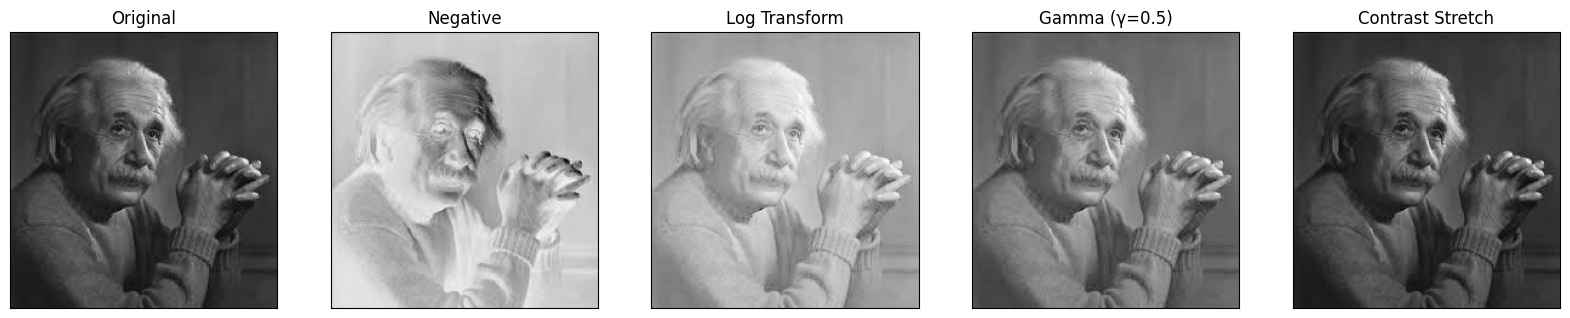

Intensity Transformations complete.


In [34]:
def intensity_transformations(img):

    img = img.astype(np.float64)
    L = 256   # gray levels

    # 1. Image Negative
    negative = L - 1 - img

    # 2. Log Transformation: s = c * log(1 + r)
    c = (L - 1) / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img)

    # 3. Power-Law (Gamma) Transformation: s = c * r^gamma
    gamma = 0.5   # <1 brightens, >1 darkens
    c = 1.0
    gamma_img = c * np.power(img / 255.0, gamma) * 255

    # 4. Contrast Stretching: linear stretch to [0, 255]
    r_min, r_max = img.min(), img.max()
    contrast = (img - r_min) / (r_max - r_min) * 255

    images = [
        img.astype(np.uint8),
        negative.astype(np.uint8),
        log_img.astype(np.uint8),
        gamma_img.astype(np.uint8),
        contrast.astype(np.uint8)
    ]

    titles = [
        'Original',
        'Negative',
        'Log Transform',
        f'Gamma (γ={gamma})',
        'Contrast Stretch'
    ]

    show(images, titles, figsize=(20, 4))

    print("Intensity Transformations complete.")

# Function Call
intensity_transformations(img_gray)